In [4]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [5]:
samples = [
    '2Mu2E_800GeV_5p0GeV_50p0mm',
    '2Mu2E_800GeV_1p2GeV_12p0mm',
    '2Mu2E_800GeV_0p25GeV_2p5mm',
    '2Mu2E_500GeV_5p0GeV_80p0mm',
    '2Mu2E_500GeV_1p2GeV_19p0mm',
    '2Mu2E_500GeV_0p25GeV_4p0mm',
    '2Mu2E_1000GeV_5p0GeV_20p0mm',
    '2Mu2E_100GeV_5p0GeV_400mm',
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    "baseNoTriggerNoLjNoLjsource",
    ##"baseNoLjNoLjsource",
    ##"NoLjNoLjsource2dsamu",
    "noLj2dsamu",
    #"ljsource_test_dsaMuon_pt",
    #"ljsource_test_dsaMuon_eta",
    #"ljsource_test_dsaMuon_displacedID",
    ##"noLj2dsamu1mulj",
    ##"notrigger_closemuLJ",
    #"notrigger_2closemuLJ",
    ##"notrigger_closemuLJ_0charge",
    #"noLj1dsamu",
    ##"noLj2dsamu2mulj",
    #"notrigger_1dsamu",
    "notrigger_2dsamu",
    #"notrigger_2dsamu1muLJ",
    #"notrigger_2dsamu1muLJ_0charge",
    #"baseNoLj",
    #"notrigger_1pfmu",
    "notrigger_2pfmu",
    #"noLj1pfmu",
    "noLj2pfmu",
    #"notrigger_1dsamu_ljsource",
    "notrigger_2dsamu_ljsource",
    #"notrigger_1pfmu_ljsource",
    "notrigger_2pfmu_ljsource",
    'NoLjNoLjsource2pfmu',
    'NoLjNoLjsource2dsamu',
    'notrigger_2dsamu1muLJ',
    'notrigger_2dsamu1muLJ_0charge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["genA_toMu_base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Output()

Processing 2Mu2E_800GeV_5p0GeV_50p0mm


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XXLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_MuMudR_highRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_highRange_MuMudR_lowRange could not be filled and will be skipped

Signal not in xs cfg, assuming 1fb


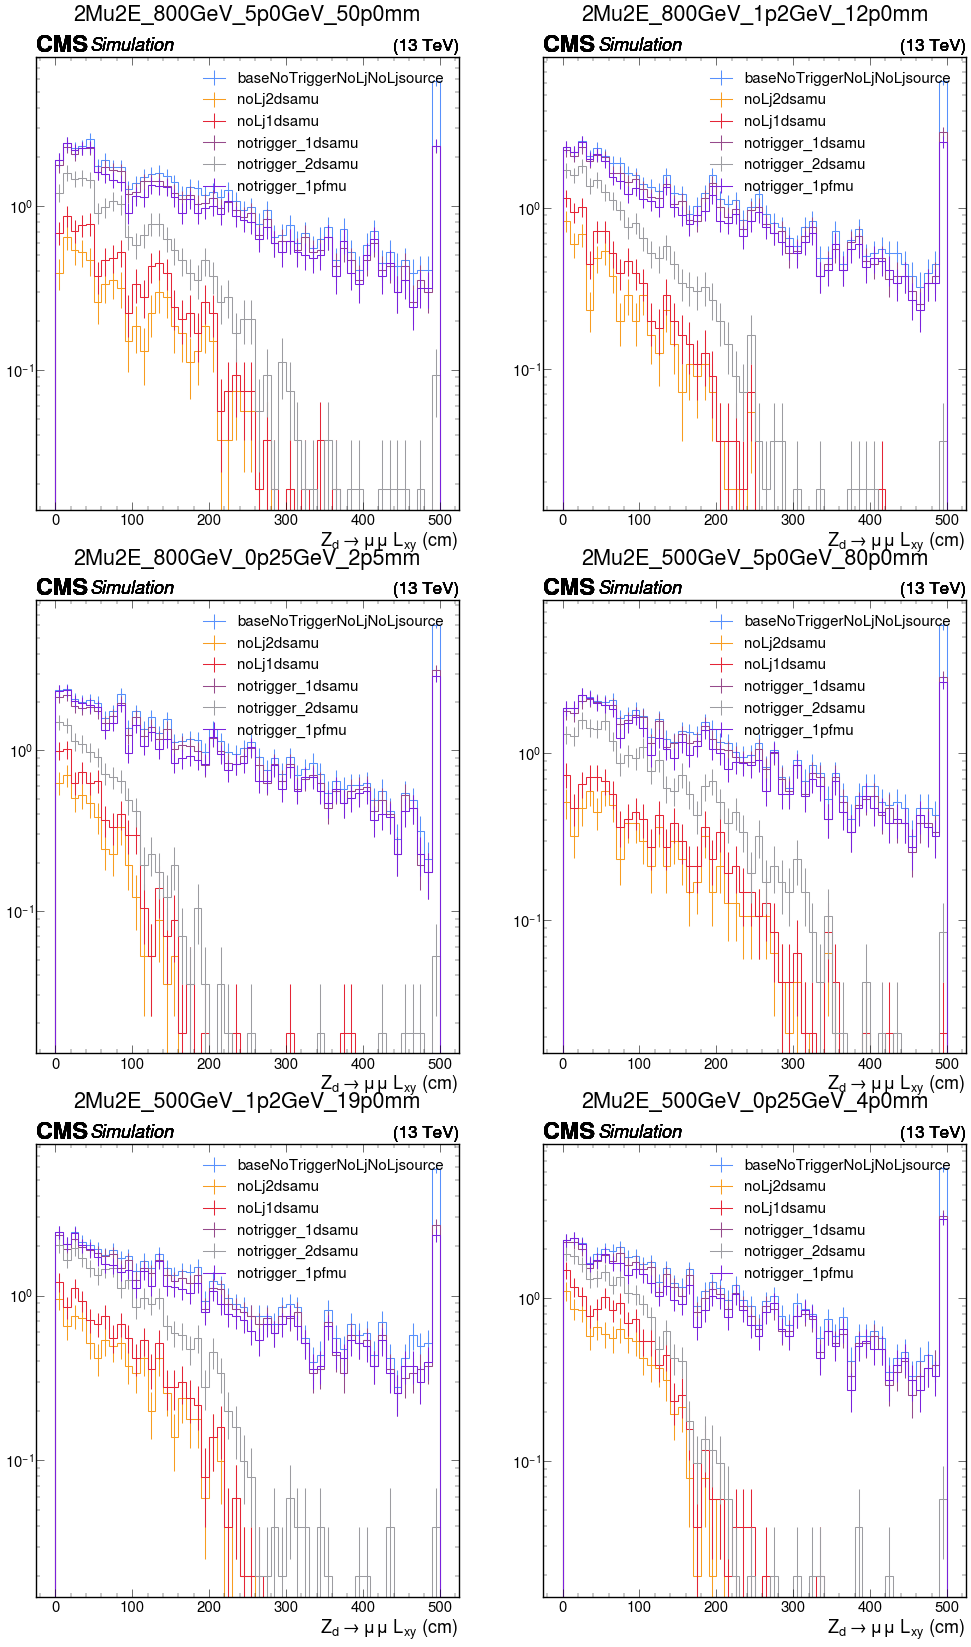

In [3]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 1
    channel3 = 2
    channel4 = 3
    channel5 = 4
    channel6 = 5
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

Text(0.5, 1.07, '2Mu2E_800GeV_5p0GeV_50p0mm')

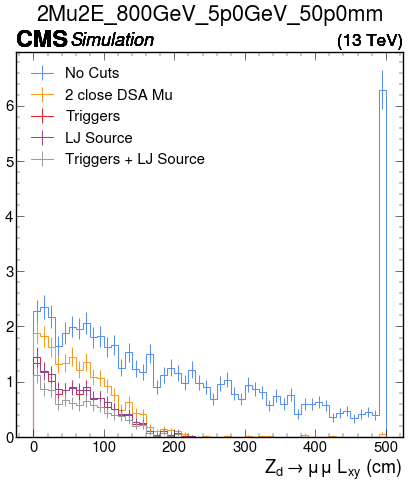

In [7]:
channel1 = 0
channel2 = 2
channel3 = 8
channel4 = 5
channel5 = 1
channel6 = 5
utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label="No Cuts")
utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label="2 close DSA Mu")
utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label="Triggers")
utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label="LJ Source")
utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label="Triggers + LJ Source")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

Text(0.5, 1.07, '2Mu2E_1000GeV_5p0GeV_20p0mm')

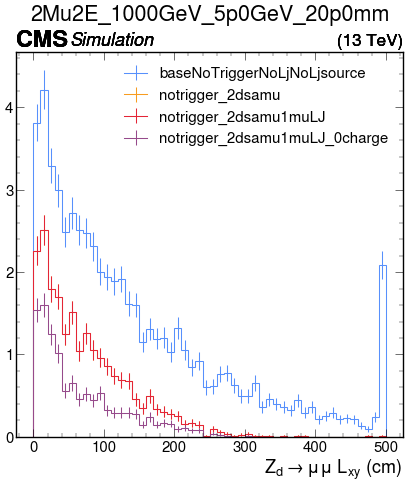

In [3]:
channel1 = 0
channel2 = 2
channel3 = 9
channel4 = 10
channel5 = 1
channel6 = 5
utilities.plot(out[samples[6]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[6]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
utilities.plot(out[samples[6]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
utilities.plot(out[samples[6]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
#utilities.plot(out[samples[6]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label="Triggers + LJ Source")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
#plt.yscale("log")
plt.legend()
plt.title(samples[6],y=1.07)

Text(0.5, 1.07, '2Mu2E_800GeV_5p0GeV_50p0mm')

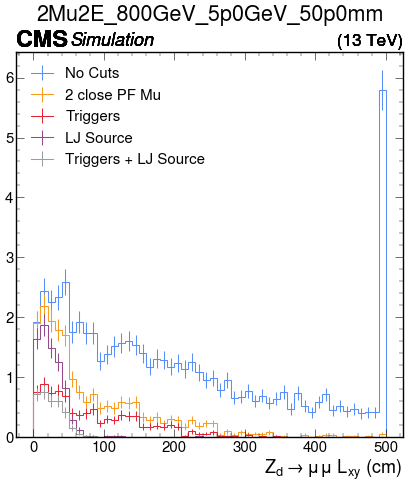

In [6]:
channel1 = 0
channel2 = 3
channel3 = 7
channel4 = 6
channel5 = 4
channel6 = 5
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label="No Cuts")
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label="2 close PF Mu")
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label="Triggers")
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label="LJ Source")
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label="Triggers + LJ Source")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

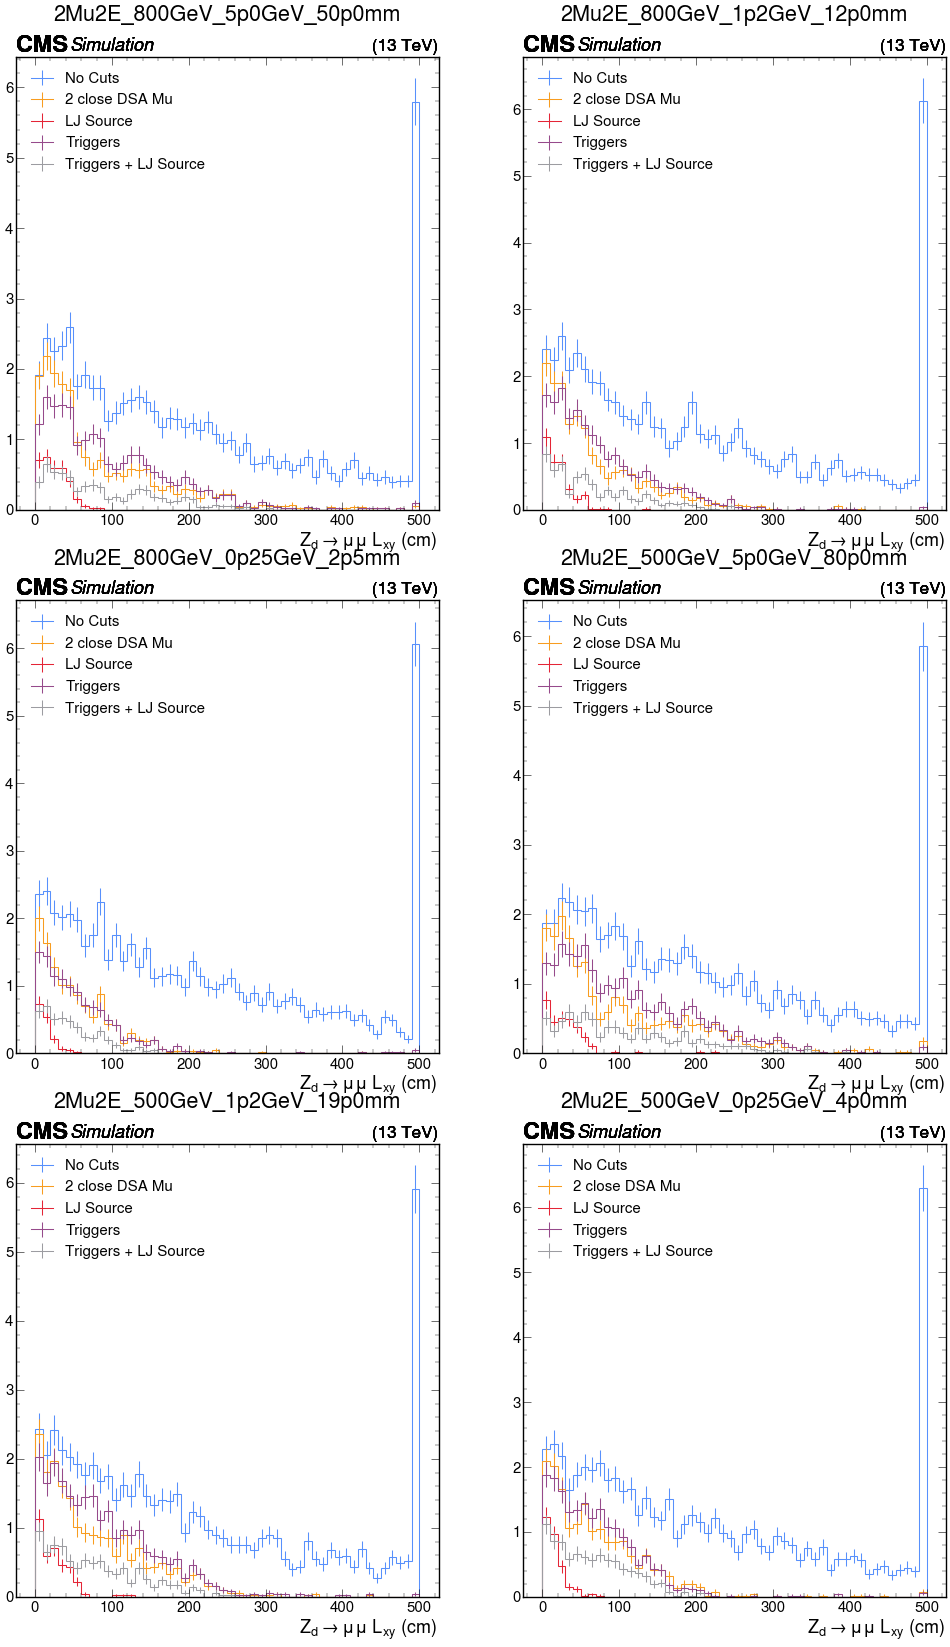

In [5]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 3
    channel3 = 4
    channel4 = 2
    channel5 = 1
    #channel6 = 5
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

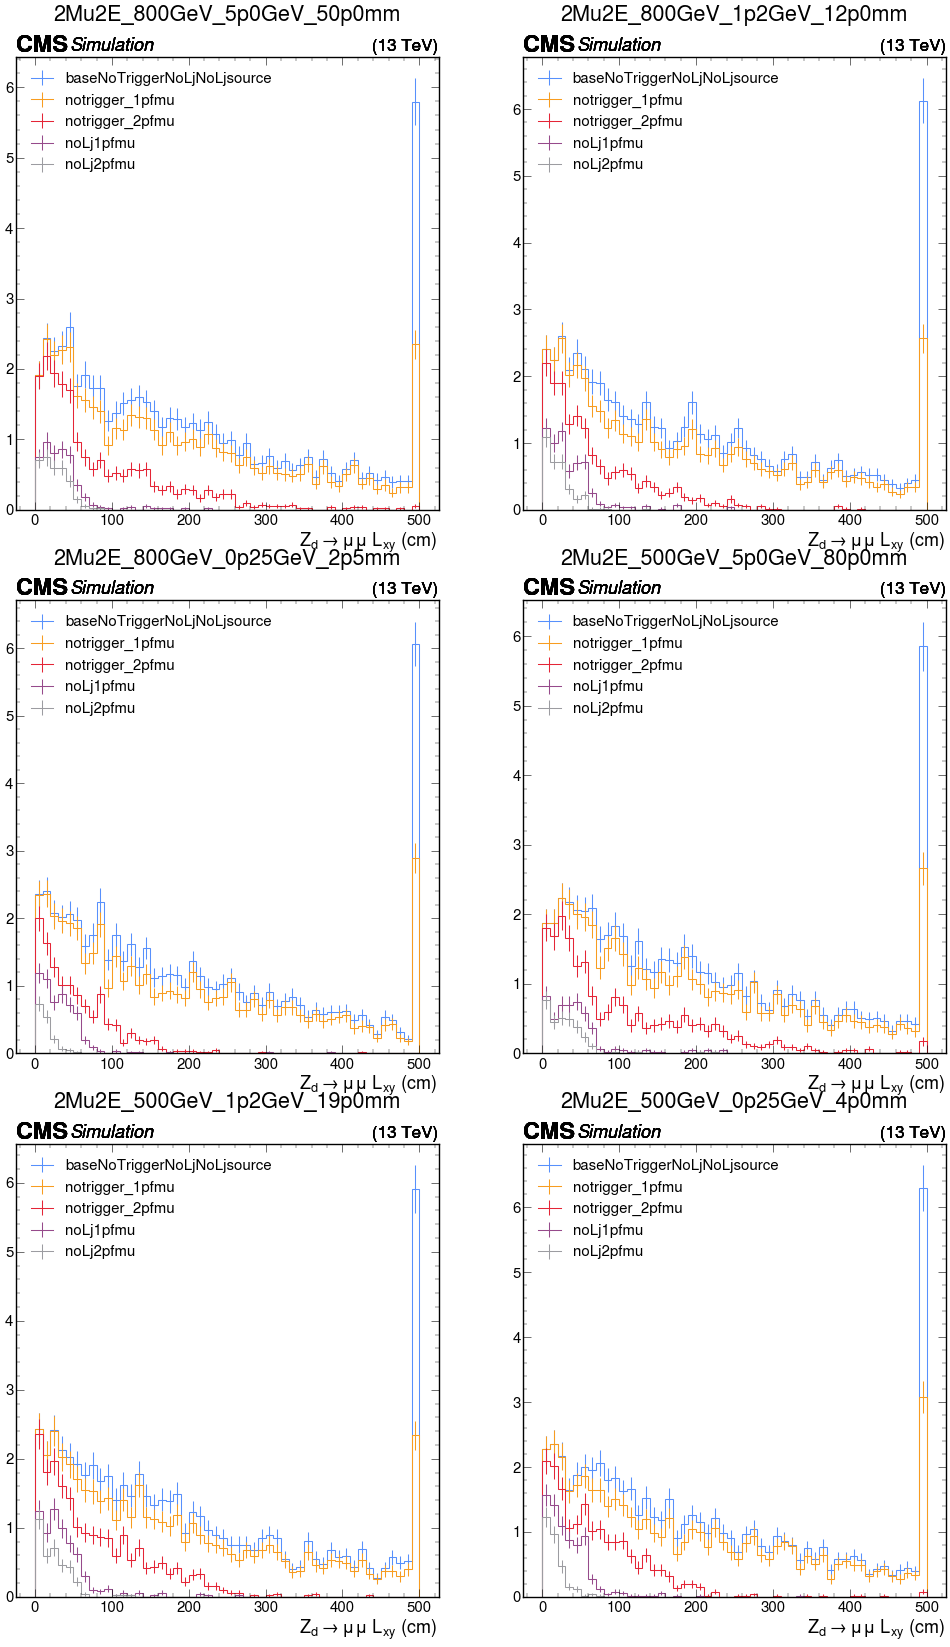

In [4]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 5
    channel3 = 6
    channel4 = 7
    channel5 = 8
    #channel6 = 5
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

/usr/local/lib/python3.10/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.10/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.10/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.10/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.10/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


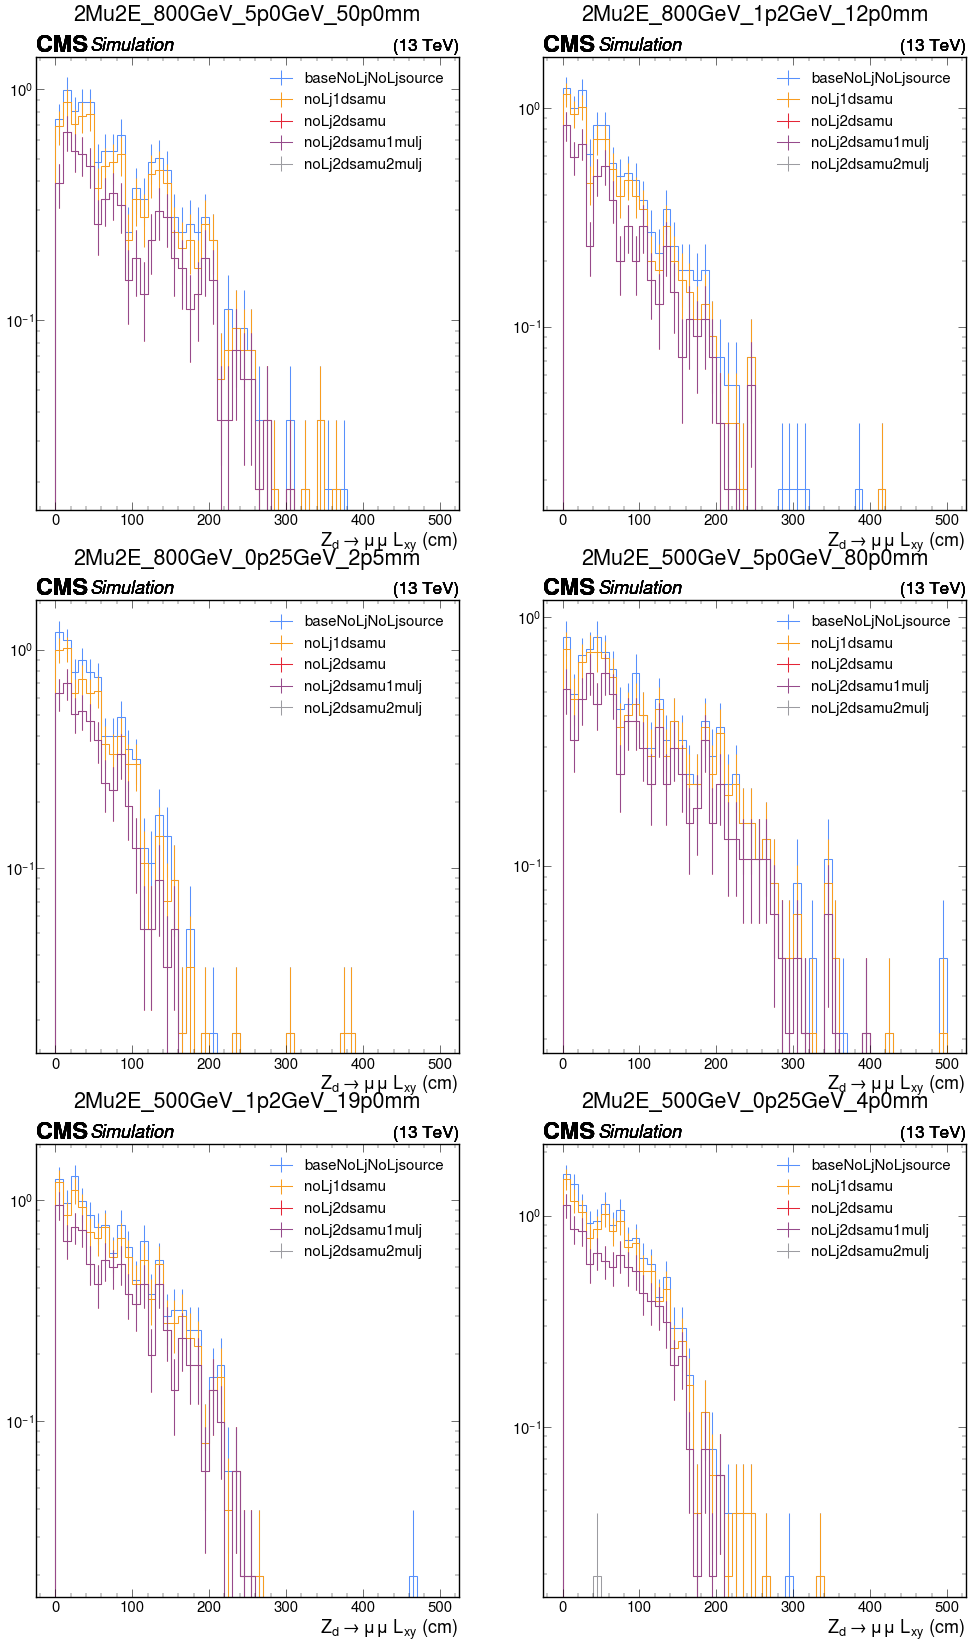

In [11]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 7
    channel3 = 3
    channel4 = 4
    channel5 = 8
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

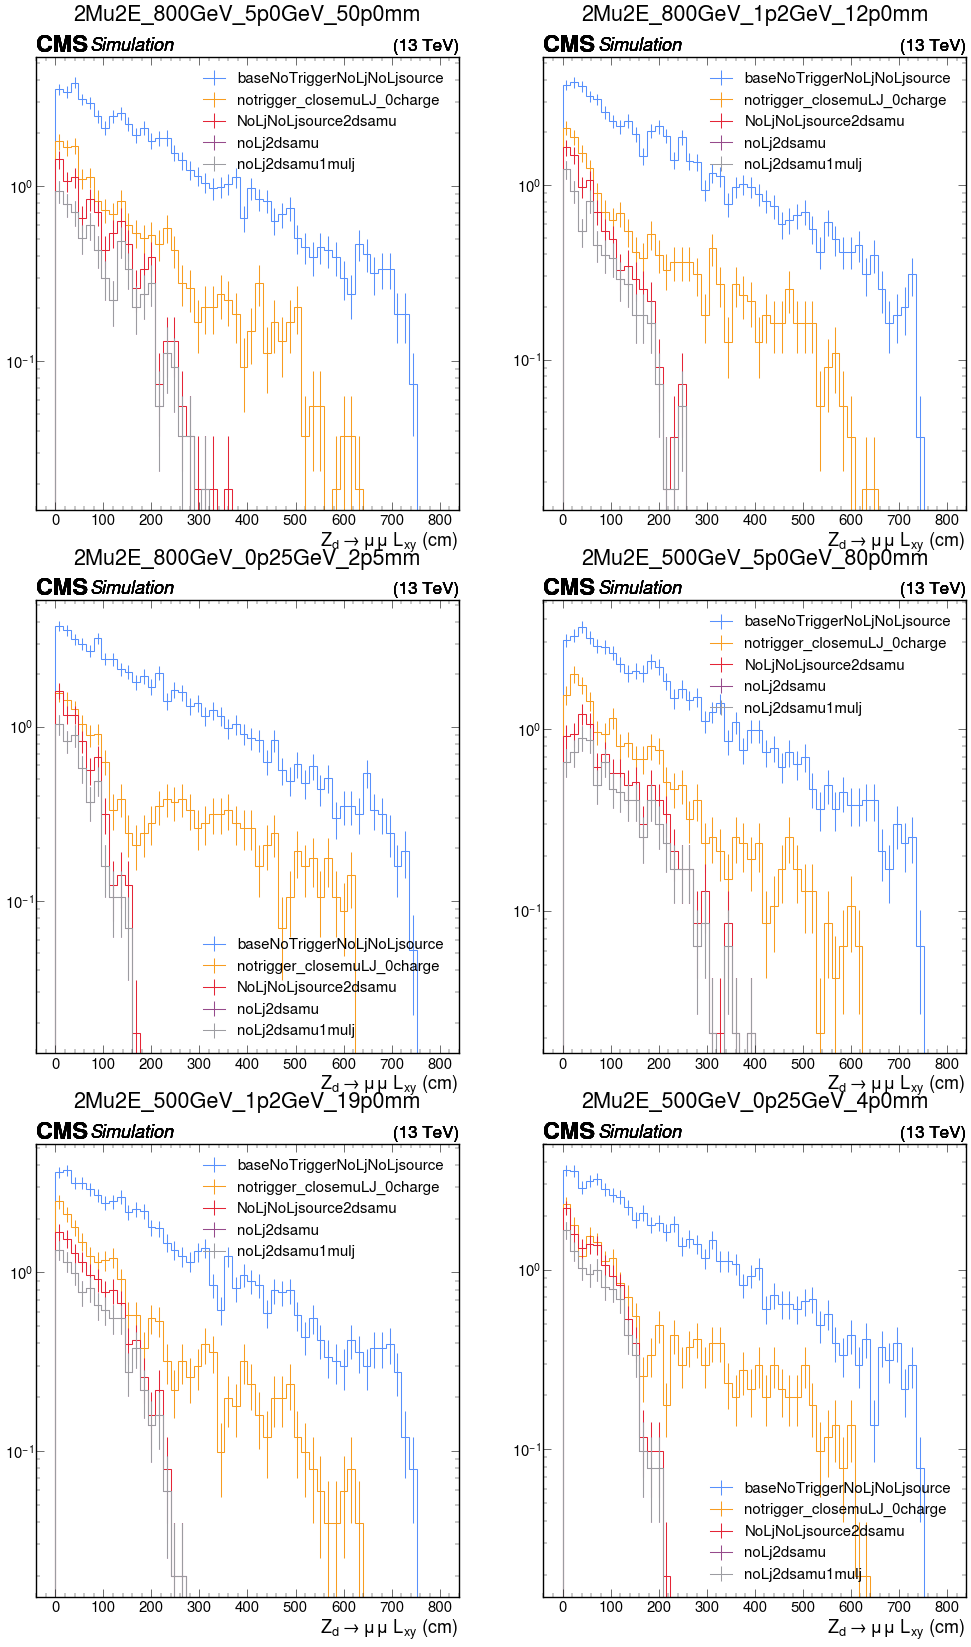

In [4]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 6
    channel3 = 2
    channel4 = 3
    channel5 = 4
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy_highRange"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy_highRange"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy_highRange"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy_highRange"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy_highRange"][channels[channel5], ::2j],label=channels[channel5])
    plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

In [87]:
new_hist = Hist.new.Reg(100,0,500).Double()
print(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1],:]).values())
#new_hist.fill(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1],:].values())
#utilities.plot(new_hist)

AttributeError: 'Hist' object has no attribute 'Double'

Text(0.5, 1.07, 'Triggers + 2 DSA Muons + displaced ID')

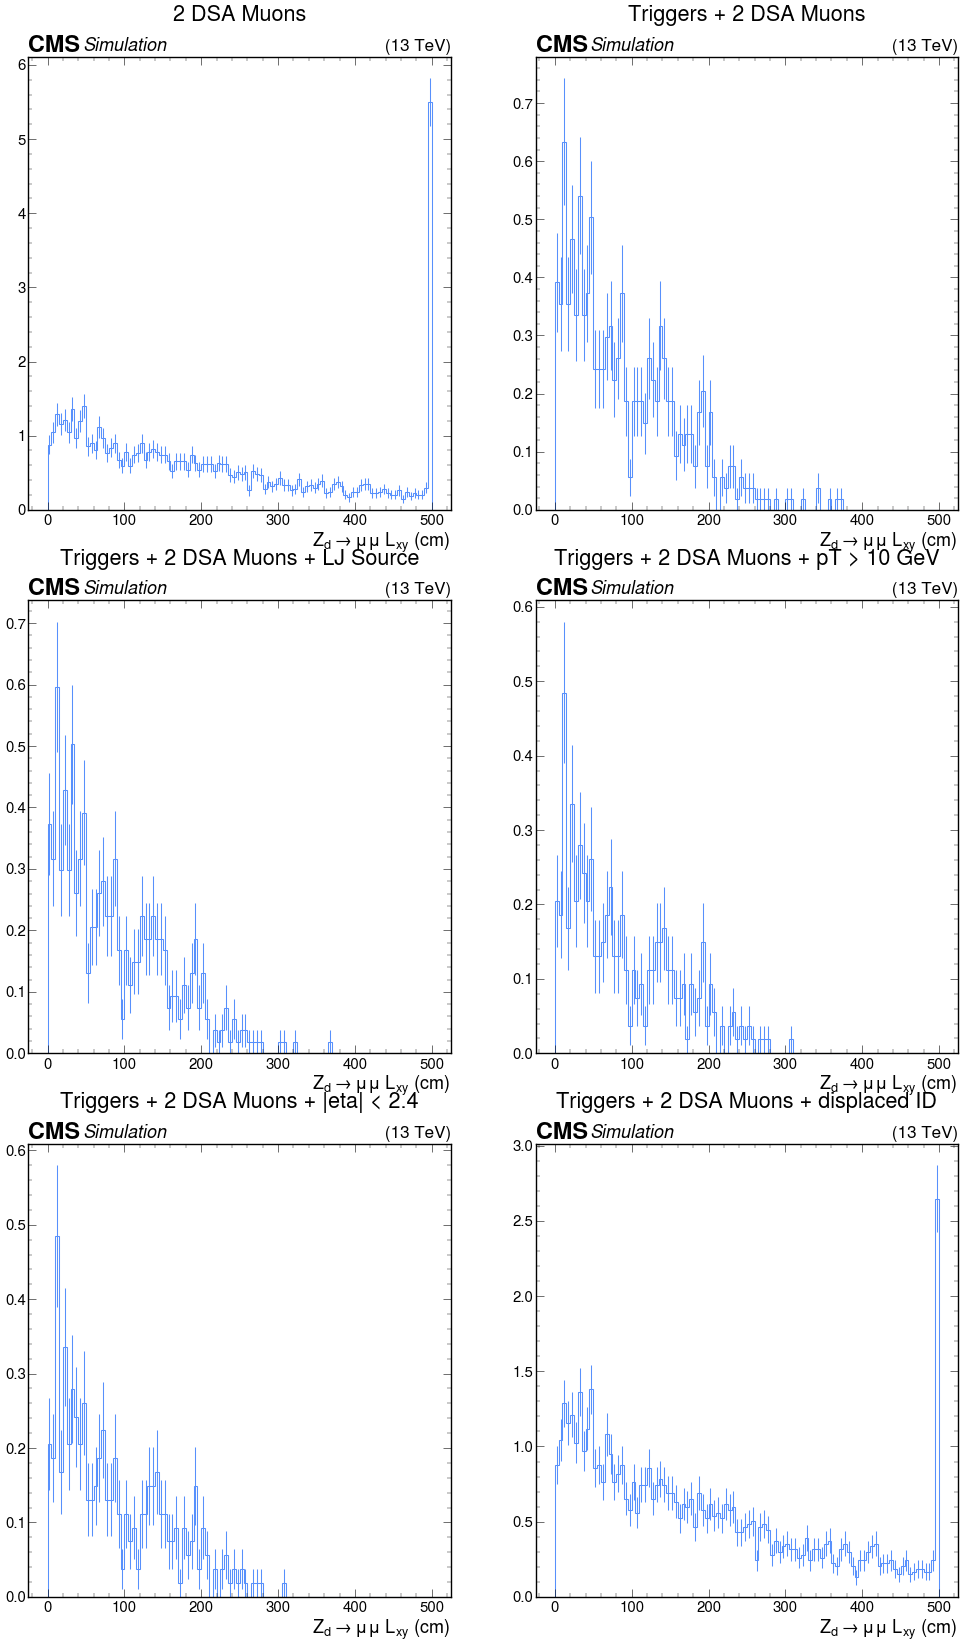

In [79]:
plt.subplots(3, 2, figsize=(24, 40))
plt.subplot(3, 2, 1)
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[0], :])
plt.title("2 DSA Muons",y=1.07)
plt.subplot(3, 2, 2)
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[1], :])
plt.title("Triggers + 2 DSA Muons",y=1.07)
#plt.yscale("log")
plt.subplot(3, 2, 3)
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[2], :])
plt.title("Triggers + 2 DSA Muons + LJ Source",y=1.07)
#plt.yscale("log")
plt.subplot(3, 2, 4)
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[3], :])
plt.title("Triggers + 2 DSA Muons + pT > 10 GeV",y=1.07)
plt.subplot(3, 2, 5)
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[4], :])
plt.title("Triggers + 2 DSA Muons + |eta| < 2.4",y=1.07)
plt.subplot(3, 2, 6)
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[5], :])
plt.title("Triggers + 2 DSA Muons + displaced ID",y=1.07)

/usr/local/lib/python3.10/site-packages/sidm/tools/utilities.py:144: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals


Text(0.5, 3.1, 'DSA Muon all Lj Source')

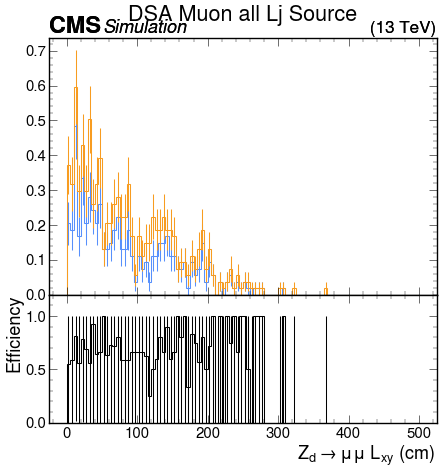

In [7]:
utilities.plot_ratio(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[2], :],out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[1], :])
plt.title("DSA Muon all Lj Source",y=3.1)

/usr/local/lib/python3.10/site-packages/sidm/tools/utilities.py:144: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals


Text(0.5, 3.1, 'DSA Muon pT > 10 GeV')

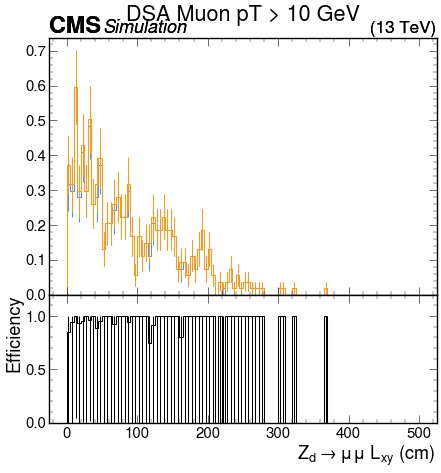

In [8]:
utilities.plot_ratio(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[3], :],out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[1], :])
plt.title("DSA Muon pT > 10 GeV",y=3.1)

/usr/local/lib/python3.10/site-packages/sidm/tools/utilities.py:144: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals


Text(0.5, 3.1, 'DSA Muon |eta| < 2.4')

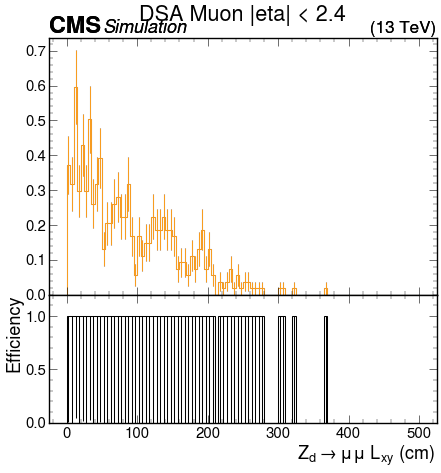

In [9]:
utilities.plot_ratio(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[4], :],out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[1], :])
plt.title("DSA Muon |eta| < 2.4",y=3.1)

/usr/local/lib/python3.10/site-packages/sidm/tools/utilities.py:144: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals


Text(0.5, 3.1, 'DSA Muon displaced ID')

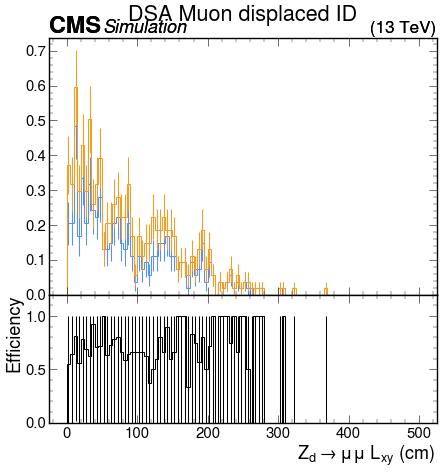

In [10]:
utilities.plot_ratio(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[5], :],out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[1], :])
plt.title("DSA Muon displaced ID",y=3.1)

Text(0.5, 3.1, 'DSA Muon displaced ID')

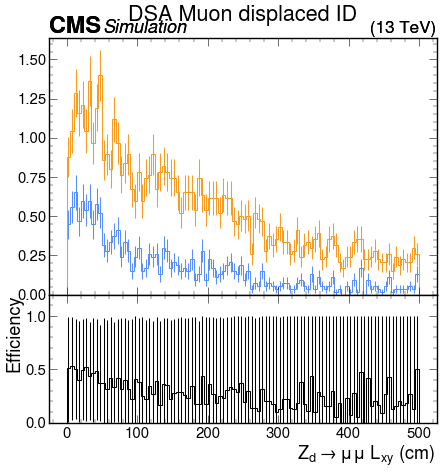

In [3]:
utilities.plot_ratio(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[6], :],out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[0], :])
plt.title("DSA Muon displaced ID",y=3.1)